#  Derivative Pricing & Volatility Modelling

## Project Overview

This project is an exploration into the evolution of option pricing methodologies, beginning from classical constant volatility frameworks to more advanced non Markovian rough volatility regimes. The purpose of this project was for me to explore these concepts, while learning and implementing them simultaneously.

The project roughly flows as follows:

1. Foundational option pricing - 
Beginning with Geometric Brownian Motion (GBM), and the Black-Scholes model. We develop crude Monte Carlo simulation paths for standard European options and validate their accuracy directly against analytical closed form solutions.

2. Extension to Path Dependent Derivatives - 
This portion explores some more exotic options to see how the framework in section 1 can be applied directly.

3. Simulation Efficiency, Variance Reduction - 
Crude Monte Carlo simulations have a slow convergence rate, we implement and try out a Control Variate (CV) scheme to try to achieve a large variance reduction factor that accelerates convergence precision.

4. Relaxing Volatility Constraints with the Heston Model - 
GBM provides a solid baseline, but its assumption of constant volatility fails to replicate real world market dynamics, such as the volatility smile or skew implied volatility surfaces. We transition to the Heston Stochastic Volatility Model, treating variance as a coupled, mean reverting stochastic process that incorporates asset volatility correlation to capture the leverage effect. 

5. Capturing Market Microstructure with Rough Volatility - 
By relaxing the Markovian assumption entirely, we implement a Rough Volatility model driven by Fractional Brownian Motion (fBM) with a low Hurst parameter ($H \approx 0.1$). We try to replicate the short-term implied volatility smiles observed in live options markets.



# Option pricing with Monte Carlo methods and Geometric Brownian Motion

We will start by exploring  Monte Carlo Methods for pricing options, where we assume the underlying follows Geometric Brownian Motion.

The motivation behind using this as a starting point is such that we can initially compare some results to Black Scholes, which of course has a famous closed form solution for the price of a European Call option under GBM assumptions. This would provide a good comparison point to the analytical closed form solution.

For some brief introduction:

The Stochastic process $St$ is said to follow Geometric Brownian motion if it follows the SDE below

$$dSt = \mu Stdt + \sigma StdWt$$

The solution to this SDE is

$$St = S0 * exp((\mu - \sigma^2/2)t + \sigma Wt)))$$

Let us begin by using Monte Carlo methods to estimate the value of an option under the GBM equations above

We can estimate this crudely via the Euler-Maruyama method (i.e. typical Euler method where we calculate the value in discrete steps, where we utilize the derivative multiplied by the distance, but add a 'shock' or the contribution of $\sigma$)

I.e. If we divide the total time horizon $T$ into $N$ steps, can define $\Delta t = T/N$

We can define

$$Sn+1 = Sn + \mu Sn\Delta t + \sigma Sn\epsilon\sqrt{\Delta t} = Sn(1 + \mu\Delta t + \sigma\epsilon\sqrt{\Delta t})$$

where $\epsilon \sim N(0, 1)$.

The function that does this is below

Note on discretization: Although the GBM SDE has an exact solution, the simulation here uses Maruyama discretization, because path dependent and stochastic volatility models introduced later in the project have no closed form path and require a discretized scheme.

**Risk-Neutral Pricing Assumption:** Throughout this entire project, we operate strictly under the risk neutral pricing measure. Consequently, the drift coefficient of the underlying asset is assumed to equal the risk-free rate $r$, ensuring all option payouts can be discounted back to time $t$ using the risk-free discount factor $e^{-r(T-t)}$.


In [1]:
#mu, sigma: mu and sigma from formula
#T = total time to option expiry
#NumInterval = number of intervals in the discretization of T into chunks
#NumTrial = number of trials in the simulation, # of chains
#S0 = starting price of S

import numpy as np

def MonteCarloGBM(r, sigma, T, NumInterval, NumTrial, S0):
    dt = T/NumInterval
    S_mat = np.zeros((NumInterval + 1, NumTrial))
    S_mat[0] = S0
    normalvec = np.random.normal(0,1,(NumInterval,NumTrial))
    
    for t in range(1,NumInterval+1):
        S_mat[t] = normalvec[t-1] * sigma * np.sqrt(dt)
        S_mat[t] += (1 + r * dt)
        S_mat[t] *= S_mat[t-1]
        
    return S_mat

We can test the result below, for 100 intervals and 1000 different trial / realizations of the simulation

In [2]:
r = 0.05
sigma = 0.4
T = 1
NumInterval = 1000
NumTrial = 1000
S0 = 100
S = MonteCarloGBM(r, sigma, T, NumInterval, NumTrial, S0)

We can see from the plot below what each trial looks like (for first 10 realizations), it visually appears to follow the GBM

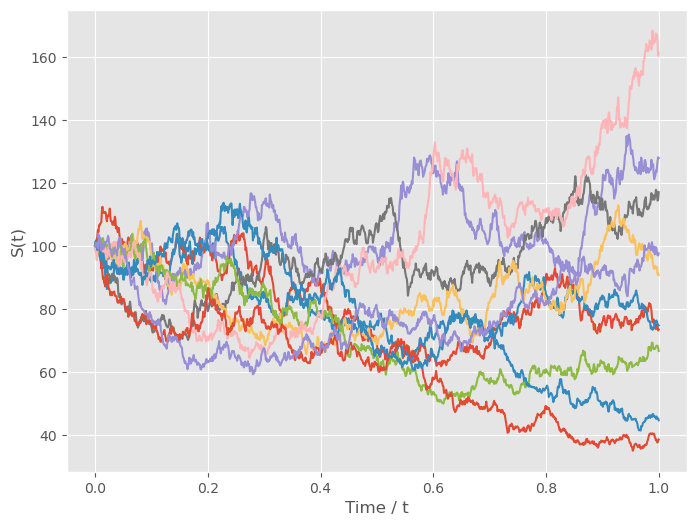

In [3]:
import matplotlib.pyplot as plt

#set x axis to time value
dt = T/NumInterval
x_time = np.arange(0,T+dt*0.1,dt)

plt.style.use('ggplot')
plt.figure(figsize=(8, 6))
plt.plot(x_time,(S[:, :10]))
plt.xlabel('Time / t')
plt.ylabel('S(t)')
plt.show()

To check if the desired result makes sense, we can also check the distribution of the final values

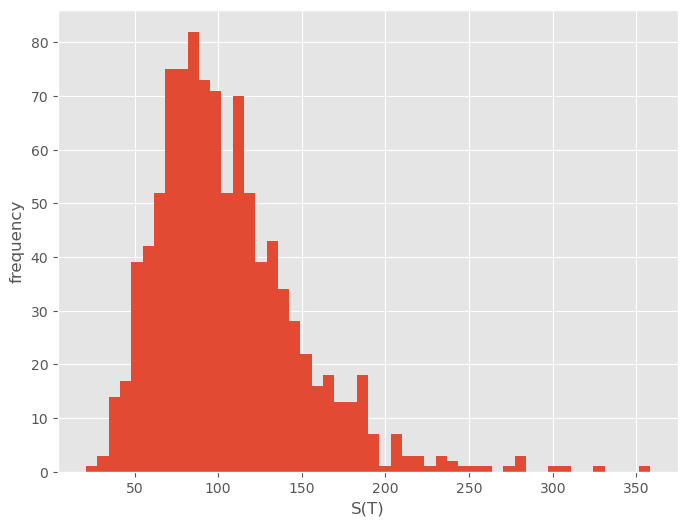

In [4]:
plt.figure(figsize=(8,6))
plt.hist(S[-1], bins=50)
plt.xlabel('S(T)')
plt.ylabel('frequency')
plt.show()


We see that the distribution is log normal, albeit a bit chunky due to the number of sample points. We can run it again, with more points to check if this resolves.

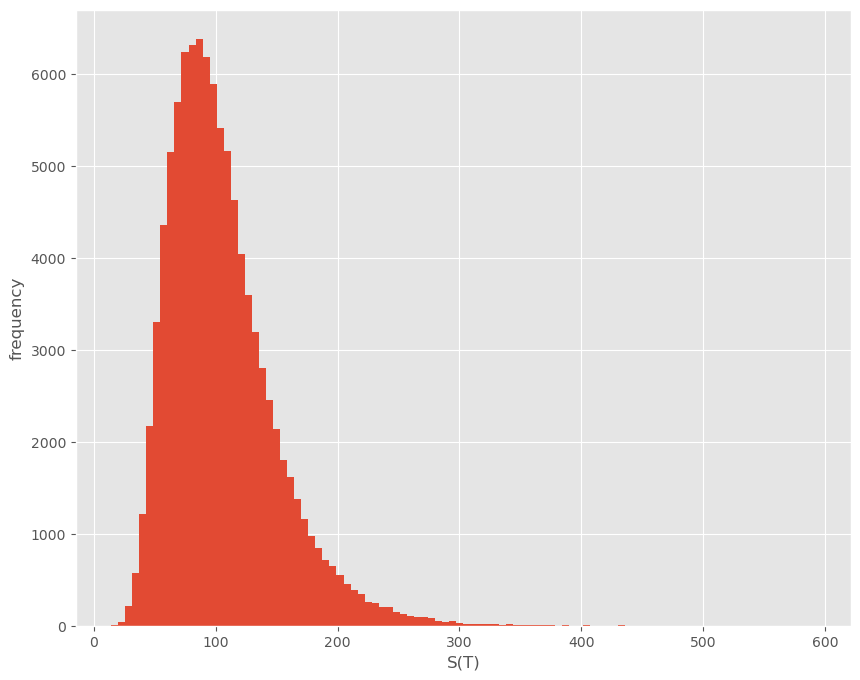

In [5]:
NumTrial = 100000
S = MonteCarloGBM(r, sigma, T, NumInterval, NumTrial, S0)

plt.figure(figsize=(10, 8))
plt.hist(S[-1], bins=100)
plt.xlabel('S(T)')
plt.ylabel('frequency')
plt.show()


As expected, the distribution tends closer to the log normal

Next step is to map this stock value to the value of the option. Let's consider a call option with strike price $K$. 
The payoff is $$\
p(S_{T}) = \max \left( S_{T}-K,0\right)\,.
$$

We can directly calculate the value of the option at time t and expiry T, by calculating all of the paths as in the steps before, calculating the payoff, taking the mean payoff, and discounting it back. Illustrated below:

In [6]:
def MonteCarloEuropeanCallOption(S_t, Strike, r, sigma, T, t, NumInterval, NumTrial):
    S = MonteCarloGBM(r, sigma, T-t, NumInterval, NumTrial, S_t)
    finalS = S[-1]
    finalS -= Strike
    finalS[finalS<0] = 0
    
    return (np.mean(finalS)*np.e**(-r*(T-t)))

In [7]:
t = 0
K = 90
NumTrial = 100000
S_t = S0
value = MonteCarloEuropeanCallOption(S_t, K, r, sigma, T, t, NumInterval, NumTrial)
print('Value of Call Option is:', value)

Value of Call Option is: 22.852991591234808


Now we can directly compare this to Black Scholes model, to check if our methodology is correct!


The formula for the analytical solution of the Black-Scholes equation for a european call option is:
$$
C(S,t) = S\, N(d_{1}) - K\,e^{-r(T-t)}N(d_{2})\,,
$$
where:
$$
d_{1} = \frac{\ln(S/X) + \left(r + \frac{\sigma^{2}}{2}\right)\left(T-t\right)}{\sigma\sqrt{T-t}}\,,
$$
$$
d_{2} = d1 - \sigma\sqrt{T-t}
$$
and where $N(x)$ is the cumulative normal distribution:
$$
N(x)= \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{x} \; e^{-t^{2}/2} dt,.
$$

We can quickly write a function to calculate these values below:

In [8]:
from scipy import stats
def BlackScholesCallValue(S_t,K,r,sigma,T,t):
    
    d1 = (np.log(S_t/K)+(r+((sigma**2)/2))*(T-t))
    d1 /=(sigma*np.sqrt((T-t)))
    
    d2 = d1-sigma*np.sqrt((T-t))
    
    return S_t*stats.norm.cdf(d1) - K*np.exp(-r*(T-t))*stats.norm.cdf(d2)

Now we can directly compare the two

In [9]:
NumTrial = 300000
value = MonteCarloEuropeanCallOption(S_t, K, r, sigma, T, t, NumInterval, NumTrial)
print('Value of Call Option via Monte Carlo is:', value)

valueBS = BlackScholesCallValue(S_t, K, r, sigma, T, t)
print('Value of Call Option via Black Scholes is:', valueBS)

Value of Call Option via Monte Carlo is: 23.017221548466015
Value of Call Option via Black Scholes is: 22.984789059492478


Here, we see the result is extremely similar, which we would expect given the equivalence of these two methods

In [10]:
x = np.zeros(250)
x2 = 1*x
t = np.linspace(0,1,250)
for i in range(250):
    value = MonteCarloEuropeanCallOption(S_t, K, r, sigma, T,t[i], 100, 100000)
    value2 = BlackScholesCallValue(S_t, K, r, sigma, T,t[i])
    x[i] = value
    x2[i] = value2

C:\Users\natpe\AppData\Local\Temp\ipykernel_14932\3535169620.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  d1 /=(sigma*np.sqrt((T-t)))


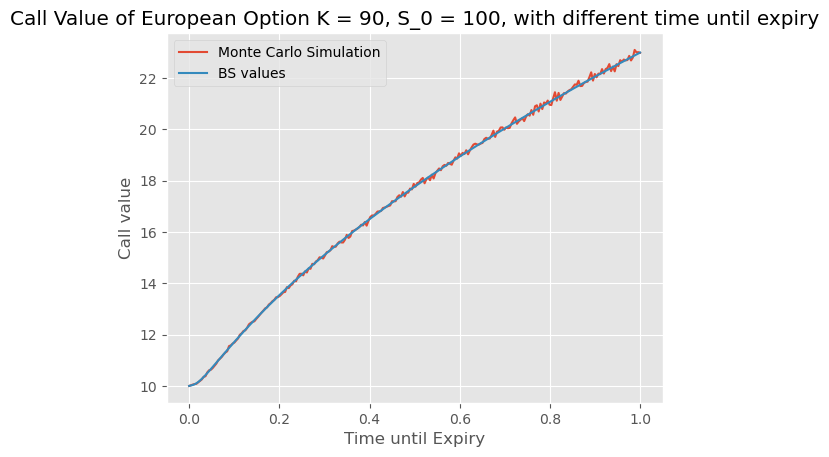

In [11]:
plt.plot(np.flip(t),x)
plt.plot(np.flip(t),x2)
plt.xlabel('Time until Expiry')
plt.title('Call Value of European Option K = 90, S_0 = 100, with different time until expiry')
plt.ylabel('Call value')
plt.legend(['Monte Carlo Simulation', 'BS values'])
plt.show()

# Exotic Options

Now that we have tested how to use Monte Carlo simulation to price a standard European option modelled by the Black Scholes model, we will now move on to more complicated option types, ones that we cannot analytically solve like in the BS model.

(For now we will continue to simulate the paths of the underlying price via the GBM model (later we will explore different models).

For different types of trivial options, we can directly look at the simulated path, and directly use this data to calculate average payoff, and price the option.

Let's start with a simple Asian option with a fixed strike price $K$, where 
$C(T) = max(A(0,T) - K,0)$, where $A$ is the average price over period $[0,T]$

Similarly to the european call option, we can immediately estimate the value of an option via the simulated Monte Carlo data

Let's take the same underlying as the previous example to illustrate the difference

In [12]:
def MonteCarloAsianCallOption_fixedstrike(S_t, Strike, mu, sigma, T, t, NumInterval, NumTrial):

    S = MonteCarloGBM(mu, sigma, T-t, NumInterval, NumTrial, S_t)

    finalS = np.mean(S,axis=0) - Strike
    finalS[finalS<0] = 0
    
    return np.mean((np.mean(finalS)*np.e**(-mu*(T-t))))

In [13]:
t = 0
NumTrial = 50000
P = MonteCarloAsianCallOption_fixedstrike(S_t, K, r, sigma, T, t, NumInterval, NumTrial)
print('Estimate value of Asian Call Option:', P)

Estimate value of Asian Call Option: 15.689990856250292


Similarly, we can also calculate the value of a floating strike Asian call option payout, with payoff
$C(T) = max(S(T)-A(T),0)$


In [14]:
def MonteCarloAsianCallOption_floatingstrike(S_t, Strike, r, sigma, T, t, NumInterval, NumTrial):

    S = MonteCarloGBM(r, sigma, T-t, NumInterval, NumTrial, S_t)

    finalS = S[-1] - np.mean(S,axis=0)
    finalS[finalS<0] = 0
    
    return np.mean((np.mean(finalS)*np.e**(-r*(T-t))))

In [15]:
P = MonteCarloAsianCallOption_floatingstrike(S_t, K, r, sigma, T, t, NumInterval, NumTrial)
print('Estimate value of Asian Call Option:', P)

Estimate value of Asian Call Option: 10.25978364902232


And as expected, the price of an asian option is cheaper than the European counterpart, due to the averaging effect

Similarly, it is trivial to estimate the value of other option types that simply require us to look at the paths, such as lookback option prices
i.e. For a fixed strike
$C(T) = max(A(T)-K,0)$, where $A(t) = max(S(t)), 0 \leq t \leq T$ 

and for a floating strike we have
$C(T) = max(S(T)-A(T),0)$, where $A(t) = min(S(t)), 0 \leq t \leq T$ 


In [16]:
def MonteCarloLookbackCallOption_fixedstrike(S_t, Strike, r, sigma, T, t, NumInterval, NumTrial):

    S = MonteCarloGBM(r, sigma, T-t, NumInterval, NumTrial, S_t)

    finalS = np.max(S,axis=0) - Strike
    finalS[finalS<0] = 0
    
    return np.mean((np.mean(finalS)*np.e**(-r*(T-t))))
def MonteCarloLookbackCallOption_floatingstrike(S_t, Strike, r, sigma, T, t, NumInterval, NumTrial):

    S = MonteCarloGBM(r, sigma, T-t, NumInterval, NumTrial, S_t)

    finalS = S[-1] - np.min(S,axis=0)
    finalS[finalS<0] = 0
    
    return np.mean((np.mean(finalS)*np.e**(-r*(T-t))))

In [17]:
x = np.zeros((250,5))
t = np.linspace(0,1,250)
for i in range(250):
    x[i,0] = MonteCarloEuropeanCallOption(S_t, K, r, sigma, T,t[i], 100, 50000)
    x[i,1] = MonteCarloAsianCallOption_fixedstrike(S_t, K, r, sigma, T,t[i], 100, 50000)
    x[i,2] = MonteCarloAsianCallOption_floatingstrike(S_t, K, r, sigma, T,t[i], 100, 50000)
    x[i,3] = MonteCarloLookbackCallOption_fixedstrike(S_t, K, r, sigma, T,t[i], 100, 50000)
    x[i,4] = MonteCarloLookbackCallOption_floatingstrike(S_t, K, r, sigma, T,t[i], 100, 50000)

We can again plot what the price curves of the different option types look like

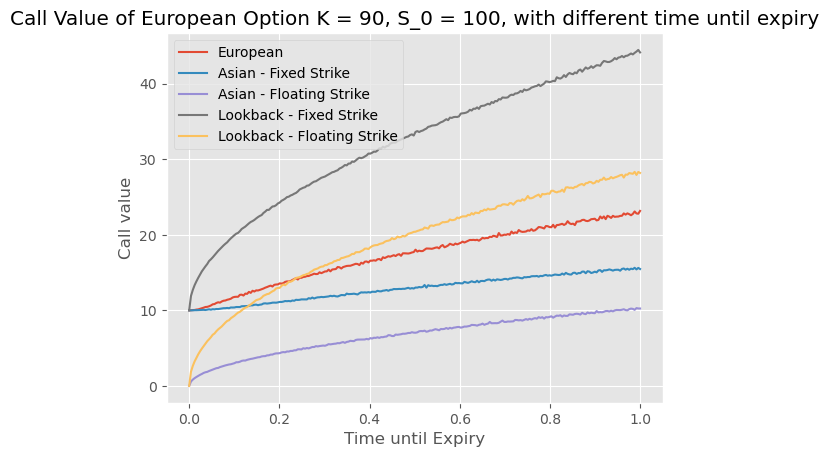

In [18]:
for i in range(5):
    plt.plot(np.flip(t),x[:,i])

plt.xlabel('Time until Expiry')
plt.title('Call Value of European Option K = 90, S_0 = 100, with different time until expiry')
plt.ylabel('Call value')
plt.legend(['European', 'Asian - Fixed Strike','Asian - Floating Strike', 'Lookback - Fixed Strike', 'Lookback - Floating Strike'])
plt.show()

### Simulation Efficiency via Control Variates

While Monte Carlo methods are nice because they are highly flexible, one downside is that it converges slowly, with a rate of $\mathcal{O}(1/\sqrt{N})$. This means the code becomes way too slow, especially when we try to price more complicated derivatives. To fix this, we explore a variance reduction technique called a Control Variate (CV) scheme to speed up our simulation without needing to generate tons of paths.

The main idea is to find a secondary asset or statistic that is highly correlated with the target option we want to price, and also has a known closed form solution.

For an arithmetic Asian option (arithmetic mean), the suitable choice is a Geometric Asian option (geometric mean). Under our standard GBM assumptions, the geometric mean of the stock paths stays log-normal, which is a nice and clean analytical baseline to compare against. 

If we let $Y$ be the discounted payoff of our unpriced Arithmetic Asian option, and $X$ be the discounted payoff of the Geometric Asian option (where we can easily calculate $\mathbb{E}[X]$ analytically), we can set up our adjusted estimator like this:

$$Y_{CV} = Y - \beta(X - \mathbb{E}[X])$$

Where $\beta$ is a fixed scalar adjustment coefficient. It is obvious that this estimator is unbiased for $Y$.

The variance of this controlled estimator is given by:

$$\text{Var}(Y_{CV}) = \text{Var}(Y) + \beta^2\text{Var}(X) - 2\beta\text{Cov}(Y, X)$$

To optimize the process we want to find the optimal parameter $\beta^*$ that minimizes $\text{Var}(Y_{CV})$, we differentiate with respect to $\beta$ and set the derivative to zero, yielding:

$$\beta^* = \frac{\text{Cov}(Y, X)}{\text{Var}(X)}$$

Substituting the optimal coefficient $\beta^*$ back into our variance formula will give

$$\text{Var}(Y_{CV}) = \text{Var}(Y) (1 - \rho_{XY}^2)$$ where $\rho_{XY}$ is the correlation coefficient between the arithmetic and geometric payoffs. 

Because both payoffs are derived from the exact same underlying price paths, their correlation ends up being near perfect and the $(1 - \rho_{XY}^2)$ term goes close to zero.

The exact expected value of the discrete Geometric Asian Call option, $\mathbb{E}[X]$, is evaluated via Black-Scholes pricing logic by adjusting the volatility and drift parameters to reflect the geometric averaging logic over $N$ discrete sampling steps, and the final formula is:

$$\mathbb{E}[X] = e^{-rT} [S_0e^{\mu_G T} N(d_1) - K N(d_2)]$$

Where the adjusted volatility ($\sigma_G^2$) and drift ($\mu_G$) terms are fixed by:

$$\sigma_G^2 = \sigma^2 \frac{(N + 1)(2N + 1)}{6N^2}$$

$$\mu_G = \left(r - \frac{1}{2}\sigma^2\right) \frac{N + 1}{2N} + \frac{1}{2}\sigma_G^2$$

$$d_1 = \frac{\ln(S_0/K) + \left(\mu_G + \frac{1}{2}\sigma_G^2\right) T}{\sigma_G\sqrt{T}}$$

$$d_2 = d_1 - \sigma_G\sqrt{T}$$

We can now implement some code to check if this method works as described

Crude Arithmetic Asian Price:     15.55900 +/- 0.08584
CV-Adjusted Arithmetic Price:    15.64105 +/- 0.00436
Variance Reduction Factor:        387.4557984256217


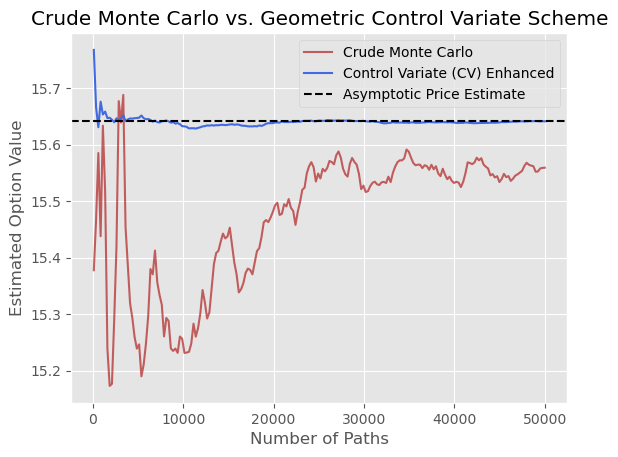

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def GeometricAsianCallExact(S0, K, r, sigma, T, N):
    
    adjustedVol=(sigma**2)*(N+1)*(2*N+1)/(6*N**2)
    drift=(r-0.5*sigma**2)*(N+1)/(2*N)+0.5*adjustedVol
    
    d1=(np.log(S0/K)+(drift+0.5*adjustedVol)*T)/np.sqrt(adjustedVol*T)
    d2=d1-np.sqrt(adjustedVol*T)
    
    return np.exp(-r*T)*(S0*np.exp(drift*T)*stats.norm.cdf(d1)-K*stats.norm.cdf(d2))


def PricingAsianOptionsWithCV(S0, K,r, sigma, T, NumInterval, NumTrial):
    
    dt=T/NumInterval
    
    normalrand=np.random.normal(0,1,(NumInterval,NumTrial))
    
    logreturns=(r-0.5*sigma**2)*dt+sigma*np.sqrt(dt)*normalrand
    
    logpaths=np.vstack([np.zeros(NumTrial),np.cumsum(logreturns,axis=0)])
    S=S0*np.exp(logpaths)
    
    arithmean=np.mean(S,axis=0)
    geommean=np.exp(np.mean(np.log(S),axis=0))
    
    discount=np.exp(-r*T)
    Yarith=np.maximum(arithmean-K,0)*discount
    Xgeom=np.maximum(geommean-K,0)*discount
    
    EXgeom=GeometricAsianCallExact(S0,K,r,sigma,T,NumInterval+1)
    
    covariancematrix=np.cov(Yarith,Xgeom)
    beta=covariancematrix[0,1]/covariancematrix[1,1]
    
    Ycv=Yarith-beta*(Xgeom-EXgeom)
    
    return Yarith,Ycv,EXgeom
    
np.random.seed(42)  

r = 0.05
sigma = 0.4
T = 1
NumInterval = 1000
NumTrial = 50000
K = 90
S0 = 100

Yarith, Ycv, geomexact = PricingAsianOptionsWithCV(S0, K, r, sigma, T, NumInterval, NumTrial)


pricecrude = np.mean(Yarith)
pricecv = np.mean(Ycv)

stderrcrude = np.std(Yarith) / np.sqrt(NumTrial)
stderrcv = np.std(Ycv) / np.sqrt(NumTrial)


print(f"Crude Arithmetic Asian Price:     {pricecrude:.5f} +/- {stderrcrude:.5f}")
print(f"CV-Adjusted Arithmetic Price:    {pricecv:.5f} +/- {stderrcv:.5f}")
print(f"Variance Reduction Factor:        {np.var(Yarith) / np.var(Ycv)}")


subsamples = np.linspace(100, NumTrial, 200, dtype=int)
crudeprogression = [np.mean(Yarith[:n]) for n in subsamples]
cvprogression = [np.mean(Ycv[:n]) for n in subsamples]

plt.plot(subsamples, crudeprogression, label='Crude Monte Carlo', color='firebrick', alpha=0.7)
plt.plot(subsamples, cvprogression, label='Control Variate (CV) Enhanced', color='royalblue', linewidth=1.5)

plt.axhline(pricecv, color='black', linestyle='--', label='Asymptotic Price Estimate')
plt.title('Crude Monte Carlo vs. Geometric Control Variate Scheme')
plt.xlabel('Number of Paths')
plt.ylabel('Estimated Option Value')
plt.legend()
plt.show()


We can see that the simulation yields a very large variance reduction factor of 387x, which is very significant. And clearly from the plot we can see the convergence is much more quick, and computationally efficient.


### The Heston Stochastic Volatility Model

#### Introduction and Framework

Next, we deal with the assumption of constant volatility in the BS model. This obviously isn't true when we look at any actual market data, or consider the nature of the markets. In fact, the whole concept of the implied volatility surface, a surface generated via real contract prices and calculating the implied vol via the BS formulas, is relevant because of this assumption not being true. If it were true then the implied volatility would be constant over different strikes and time expirations, but of course in real life this is not the case.

The first step towards making the simulation more realistic is to move to the Heston Stochastic Volatility Model. Instead of keeping volatility as a fixed number, the Heston model treats variance as its own separate stochastic process that pulls back toward a long term average. 

Another note is that it also lets us correlate the asset price shocks with the volatility shocks. This captures the leverage effect, which is the tendency for volatility to spike whenever the stock price drops.

The Heston model is as follows:

$$dS_t = \mu S_t dt + \sqrt{V_t} S_t dW^S_t$$
$$dV_t = \kappa(\theta - V_t) dt + \sigma_v \sqrt{V_t} dW^V_t$$

Where the two underlying Brownian motions are correlated by a parameter $\rho$:

$$\mathbb{E}[dW^S_t dW^V_t] = \rho dt$$

Here, $\kappa$ is the speed of mean reversion, $\theta$ is the long-term variance baseline, $\sigma_v$ is the volatility-of-volatility, and $\rho$ is the correlation coefficient.

For the variance process to remain strictly positive and never touch zero, the parameters must satisfy the Feller Condition:

$$2\kappa\theta > \sigma_v^2$$

I will now try out simulating some Heston data, and plot the paths to compare them to BS. I will then also try out generating a implied volatility surface, to check its non constant nature.

Note:
Simulating the joint Heston system introduces numerical issues. Under standard Euler Maruyama discretization, large random shocks can cause the discrete variance process $V_n$ to cross below zero. Of course the root of this negative value will cause some issues. We implement what is known as a Full Truncation Scheme $V_n^+ = \max(V_n, 0)$. (Note that in the final values of V_n we allow it to be negative but use the truncated version when calculating any further values in the path).

The discrete time-stepping updates are formulated as:

$$V_{n+1} = V_n + \kappa(\theta - V_n^+) \Delta t + \sigma_v \sqrt{V_n^+} \Delta W_n^V$$

$$S_{n+1} = S_n \left(1 + \mu \Delta t + \sqrt{V_n^+} \Delta W_n^S \right)$$



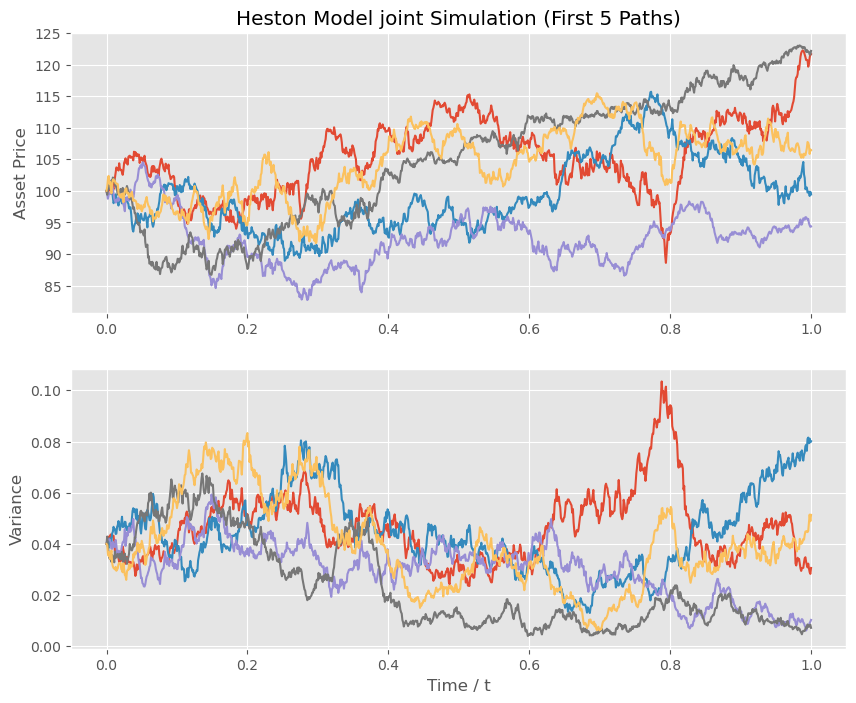

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def HestonSimulationFullTruncation(S0, V0, r, kappa, theta, sigma_v, rho, T, NumInterval, NumTrial):
    dt=T/NumInterval

    S = np.zeros((NumInterval+1,NumTrial))
    V = np.zeros((NumInterval+1,NumTrial))
    S[0] = S0
    V[0] = V0
    Z1 = np.random.normal(0,1,(NumInterval,NumTrial))
    Z2 = np.random.normal(0,1,(NumInterval,NumTrial))
    
    dW_V = Z1*np.sqrt(dt)
    dW_S = (rho*Z1 + np.sqrt(1-rho**2)*Z2)*np.sqrt(dt)
    

    for t in range(1, NumInterval+1):
        V_prev = V[t-1]
        V_pos = np.maximum(V_prev,0) 
        
        V[t] = V_prev+kappa*(theta-V_pos)*dt+sigma_v*np.sqrt(V_pos)*dW_V[t-1]
        S[t] = S[t-1]*(1+r*dt+np.sqrt(V_pos)*dW_S[t-1])
        
    return S, V


np.random.seed(42)
S0 = 100
V0 = 0.04
r = 0.05
T = 1
NumInterval = 1000
NumTrial = 10

kappa = 2.0
theta = 0.04
sigma_v = 0.3
rho = -0.7

Stock,Var = HestonSimulationFullTruncation(S0, V0, r, kappa, theta, sigma_v, rho, T, NumInterval, NumTrial)

fig,(ax1,ax2) = plt.subplots(2,1,figsize=(10,8))
xt = np.linspace(0, T, NumInterval+1)
ax1.plot(xt, Stock[:,:5])
ax1.set_ylabel('Asset Price')
ax1.set_title('Heston Model joint Simulation (First 5 Paths)')

ax2.plot(xt, Var[:,:5])
ax2.set_ylabel('Variance')
ax2.set_xlabel('Time / t')
plt.show()


We can see from the plot above that whenever an asset path undergoes a sharp downside spike, its corresponding variance path goes upward. Also when we look at the variance paths they are pulled back toward the structural long-term equilibrium baseline of $\theta = 0.04$.


## The Implied Volatility Surface

While checking a few individual paths shows that our Full Truncation simulation works without crashing, looking at just a few lines doesn't show how the Heston model behaves differently from Black-Scholes across different options. 

Visually, a single stock price path with stochastic variance looks pretty much the same as one driven by constant Geometric Brownian Motion. To actually see the difference, we can plot the implied volatility surface. Any curvature or skew we see on this surface is direct proof of the changing variance and leverage effects that the Heston model captures.

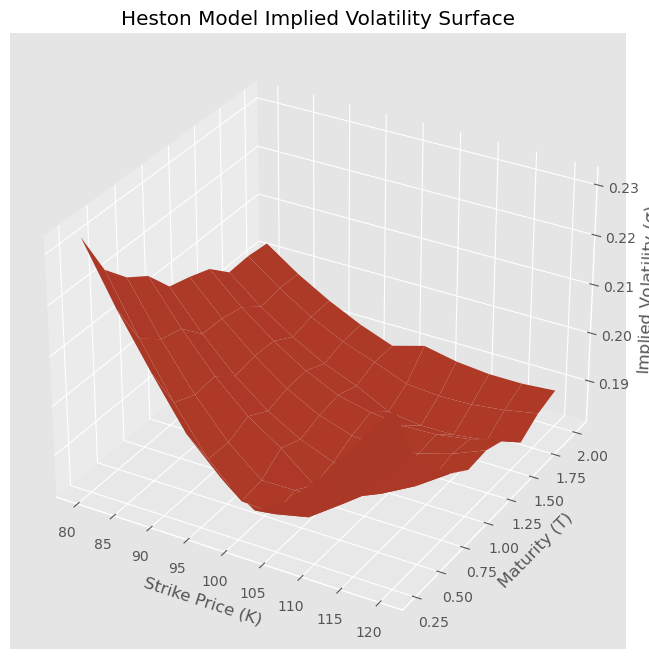

In [21]:
import numpy as np
from scipy import stats
from scipy.optimize import brentq
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


def BSvalueCallPut(S_t,K,r,sigma,T,t, optiontype):
    d1 = (np.log(S_t/K)+(r+((sigma**2)/2))*(T-t))
    d1 /=(sigma*np.sqrt((T-t)))
    
    d2 = d1-sigma*np.sqrt((T-t))

    if optiontype == 'call':
        return S_t*stats.norm.cdf(d1) -  K*np.exp(-r*(T-t))*stats.norm.cdf(d2)
    else:
        return  K*np.exp(-r*(T-t))*stats.norm.cdf(-d2) - S_t*stats.norm.cdf(-d1)

def ImpliedVolatility(S_t, K, r, T, market_price, optiontype):
    
    #define the function for the root finder function brentq
    def objective(sigma):
        return BSvalueCallPut(S_t, K, r, sigma, T, 0, optiontype) - market_price
        
    if optiontype == 'call':
        intrinsic = max(S_t-K*np.exp(-r*T),0.0)
    else:
        intrinsic = max(K*np.exp(-r*T)-S_t,0.0)
    
    if market_price <= intrinsic:
        return np.nan
        
    try:
        #set solution range to  [0.001, 3.0]
        return brentq(objective, 0.001, 3.0)
    except ValueError:
        return np.nan

def GenerateHestonVolSurface(S0, V0, mu, kappa, theta, sigma_v, rho, NumInterval, NumTrial):
    
    strikes = np.linspace(80, 120, 10)       
    maturities = np.linspace(0.25, 2.0, 10)
    volsurface = np.zeros((len(maturities), len(strikes)))

    for i,T in enumerate(maturities):
        Spaths,_=HestonSimulationFullTruncation(S0,V0,mu,kappa,theta, sigma_v,rho,T,NumInterval, NumTrial)
        
        for j,K in enumerate(strikes):
            if K < S0:
                optiontype = 'put'
                payoffs =np.maximum(K-Spaths[-1],0)
            else:
                optiontype = 'call'
                payoffs = np.maximum(Spaths[-1]-K,0)
                
            mcprice = np.mean(payoffs)*np.exp(-mu*T)      
            volsurface[i, j] = ImpliedVolatility(S0,K,mu, T,mcprice,optiontype)
            
    return strikes, maturities, volsurface

np.random.seed(42)
S0 = 100
V0 = 0.04
mu = 0.05
kappa = 2.0
theta = 0.04
sigma_v = 0.6
rho = 0

NumInterval, NumTrial = 500, 50000 

Strikes, Maturities, Vsurface = GenerateHestonVolSurface(S0,V0,mu, kappa,theta,sigma_v,rho,NumInterval, NumTrial)

X,Y =np.meshgrid(Strikes, Maturities)
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Vsurface)

ax.set_title('Heston Model Implied Volatility Surface')
ax.set_xlabel('Strike Price (K)')
ax.set_ylabel('Maturity (T)')
ax.set_zlabel('Implied Volatility ($\sigma$)')

plt.show()


For this experiment we set rho = 0 to see the volatility 'smile', and we can see it clearly in the results. Note that as described before, this surface is not a flat plane like what would occur had we simulated the data via Black Scholes.

# Rough Volatility


The Heston model does a good job introducing stochastic volatility and giving us a more realistic implied volatility surface/smile compared to just the ordinary GBM BS result, but still struggles to match how fast the short term volatility skew actually decays in real options markets. In practice, we actually see more 'sharp' surfaces on contracts.

To solve this problem, we can drop the Markovian assumption completely and look at Rough Volatility models. Instead of driving our variance path with standard Brownian motion, we  use a fractional Riemann-Liouville Volterra process with a very low Hurst parameter ($H \approx 0.1$). This should create jagged and rough variance paths that better mimic the actual exchange order books.

So the formulation is:
$$V_t = V_0 \exp\left(\eta Y_t - \frac{1}{2}\eta^2 t^{2H}\right)$$

Where $\eta$ is the volatility-of-volatility multiplier, and $Y_t$ is a Gaussian Volterra process centered at zero defined by 

$$Y_t = \int_0^t \sqrt{2H} (t - s)^{H - \frac{1}{2}} dW_s$$

The behavior of this fractional operator is  dictated by the Hurst Parameter ($H \in (0, 1)$), where if H = 0.5, we get standard Markovian Brownian Motion. And if $H > 0.5$: The increments are persistent, in that times of high vol and low vol last longer, yielding smooth, long-memory paths. And if $H < 0.5$: The increments display the opposite and when $H \approx 0.1$, the paths become very rough, matching the jagged movements seen in real asset order books.

Because this fractional Volterra process does not have independent increments, we cannot simulate it step-by-step using simple random walks. We must simulate the entire path history simultaneously using a discrete convolution kernel matrix.


To evaluate the historical paths over a discrete grid, we approximate the continuous fractional integral operator using a deterministic Volterra convolution kernel matrix $\mathbf{K}$ of size $N \times N$. 

Because the kernel depends strictly on chronological time lags, we construct $\mathbf{K}$ as a lower-triangular weighting matrix where each row accounts for all cumulative historical shocks up to step $i$:

$$K_{i, j} = \sqrt{2H} \cdot \left[ (i - j + 1)\Delta t \right]^{H - \frac{1}{2}}, \quad \text{for } j \le i$$

The full discrete historical vector array $\mathbf{Y}$ (spanning steps $1$ to $N$) is generated simultaneously across all simulation paths via a single matrix vector product:

$$\mathbf{Y} = \mathbf{K} \cdot \mathbf{dW^1}$$

$\mathbf{dW^1} \sim \mathcal{N}(0, \Delta t \cdot \mathbf{I})$ represents the underlying array of independent standard normal increments driving the variance path. To finalize the initialization conditions, an asset starting row $Y_0 = 0$ is added directly to the beginning of the matrix array.

First we try to simulate some paths, to see if our expectation of the roughness when we vary $H$ is met.



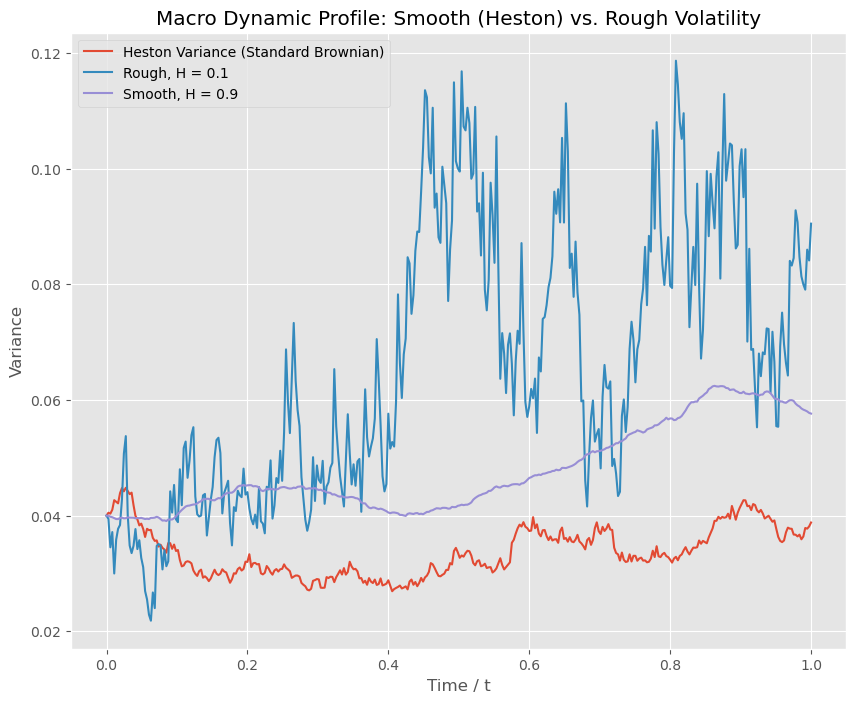

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def RoughVolatilitySimulation(S0, V0, mu, H, eta, rho, T, NumInterval, NumTrial):
    dt = T/NumInterval
    t = np.linspace(0, T,NumInterval+1)

    dW1 = np.random.normal(0,1,(NumInterval,NumTrial)) *np.sqrt(dt)

    Kmat = np.zeros((NumInterval,NumInterval))
    for i in range(NumInterval):
        js = np.arange(0,i+1)
        lag = (i+1-js)* dt
        Kmat[i,:i+1] = np.sqrt(2*H)*lag**(H-0.5)

    Y = Kmat@dW1                                 
    Y = np.vstack([np.zeros((1, NumTrial)),Y])   

    tvector = t[:,np.newaxis]
    V = V0*np.exp(eta*Y-0.5*eta**2*tvector**(2*H))
    
    dW2 = np.random.normal(0,1,(NumInterval,NumTrial)) *np.sqrt(dt)   
    dW_S = rho*dW1+np.sqrt(1-rho**2) *dW2   

    S = np.zeros((NumInterval+1,NumTrial))
    S[0]=S0
    for i in range(1,NumInterval+1):
        S[i] = S[i-1]*(1+mu*dt+np.sqrt(V[i-1])*dW_S[i-1])
    return S,V

np.random.seed(42)

S0 = 100
V0 = 0.04
r = 0.05
T = 1
NumInterval = 365  
NumTrial = 1     

kappa = 2.0
theta = 0.04
sigmav = 0.3
rho = -0.7
eta = 0.5      


_,Vpoint5= RoughVolatilitySimulation(S0, V0, r, 0.5, eta, rho, T, NumInterval, NumTrial)
_,Vrough = RoughVolatilitySimulation(S0, V0, r, 0.1, eta, rho, T, NumInterval, NumTrial)
_,Vsmooth = RoughVolatilitySimulation(S0, V0, r, 0.9, eta, rho, T, NumInterval, NumTrial)

fig, ax1 = plt.subplots(1, 1, figsize=(10, 8))
xtime = np.linspace(0,T, NumInterval+1)
ax1.set_title('Macro Dynamic Profile: Smooth (Heston) vs. Rough Volatility')
ax1.set_ylabel('Variance')
ax1.set_xlabel('Time / t')

ax1.plot(xtime, Vpoint5, label='Heston Variance (Standard Brownian)')
ax1.plot(xtime, Vrough, label='Rough, H = 0.1')
ax1.plot(xtime, Vsmooth, label='Smooth, H = 0.9')

ax1.legend()

plt.show()


We can see that clearly when we look at the variance of the paths, its much more jagged for lower values of H and smoother for higher values of H. With this in mind, we will proceed with the lower Heston value of 0.1, and generating a implied volatility surface, and see what we get.

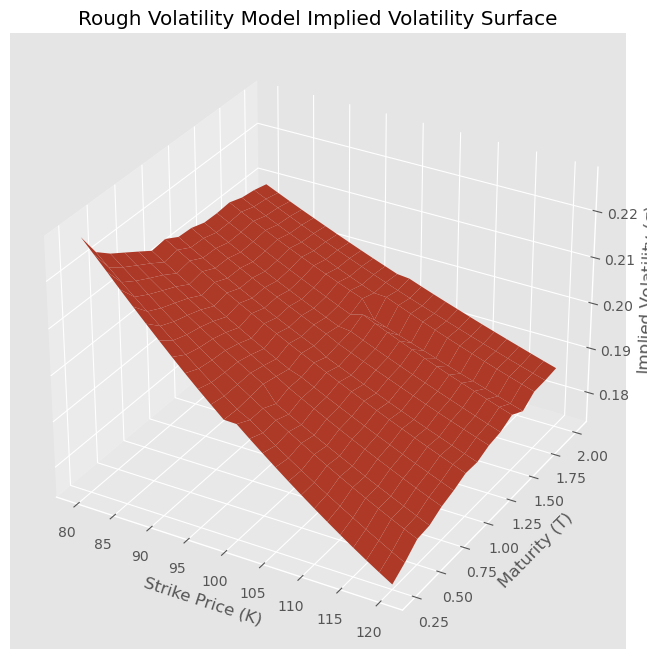

In [23]:
def GenerateRoughVolSurface(S0, V0, mu, H, eta, rho, NumInterval, NumTrial):
    strikes = np.linspace(80,120,25)
    maturities = np.linspace(0.25,2.0,15)
    volsurface = np.zeros((len(maturities),len(strikes)))
    
    for i, T in enumerate(maturities):
        S_paths, _ = RoughVolatilitySimulation(S0,V0,mu,H,eta,rho,T,NumInterval,NumTrial)
        final_prices = S_paths[-1]
        
        for j,K in enumerate(strikes):
            if K<S0:
                optiontype = 'put'
                put_payoffs = np.maximum(K-final_prices,0)
                mcprice = np.mean(put_payoffs)*np.exp(-mu*T)
            else:
                optiontype = 'call'
                call_payoffs = np.maximum(final_prices-K,0)
                mcprice = np.mean(call_payoffs)*np.exp(-mu*T)
            
            iv = ImpliedVolatility(S0,K, mu,T, mcprice, optiontype)
            volsurface[i, j] = iv if iv > 0 else np.nan

    for r in range(volsurface.shape[0]):  
        row = volsurface[r]
        mask = np.isnan(row)
        if np.any(mask) and not np.all(mask):
            row[mask] = np.interp(np.flatnonzero(mask),np.flatnonzero(~mask),row[~mask])

    return strikes, maturities, volsurface


K, T, Vsurface = GenerateRoughVolSurface(100, V0, r, 0.1, eta, -0.7, 250, 300000)
Kgrid,Tgrid = np.meshgrid(K, T)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Kgrid,Tgrid, Vsurface)
ax.set_title('Rough Volatility Model Implied Volatility Surface')
ax.set_xlabel('Strike Price (K)')
ax.set_ylabel('Maturity (T)')
ax.set_zlabel('Implied Volatility ($\sigma$)')
plt.show()


At the shortest maturity horizon $T = 0.25$, the surface seems to form a steep cliff dropping from out of the money puts down to in the money calls. This structural feature is  indicative of a rough volatility model with $H \approx 0.1$. It reflects the power law decay of the at the money skew which forces the short term skew to explode as T approaches. Traditional Markovian models like Heston yield a significantly flatter profile at short maturities due to their smoother Brownian paths.

However, it still seems a bit difficult to distinguish a true power law relationship solely from the 3d plot. To definitively isolate this behaviour from other alternative decay frameworks, we look directly at the mathematical term structure of the at the money skew. We will isolate the slope of the implied volatility curve at the money across the different maturities and plot it on a log log scale, and hope to see a straight slope in the output plot.



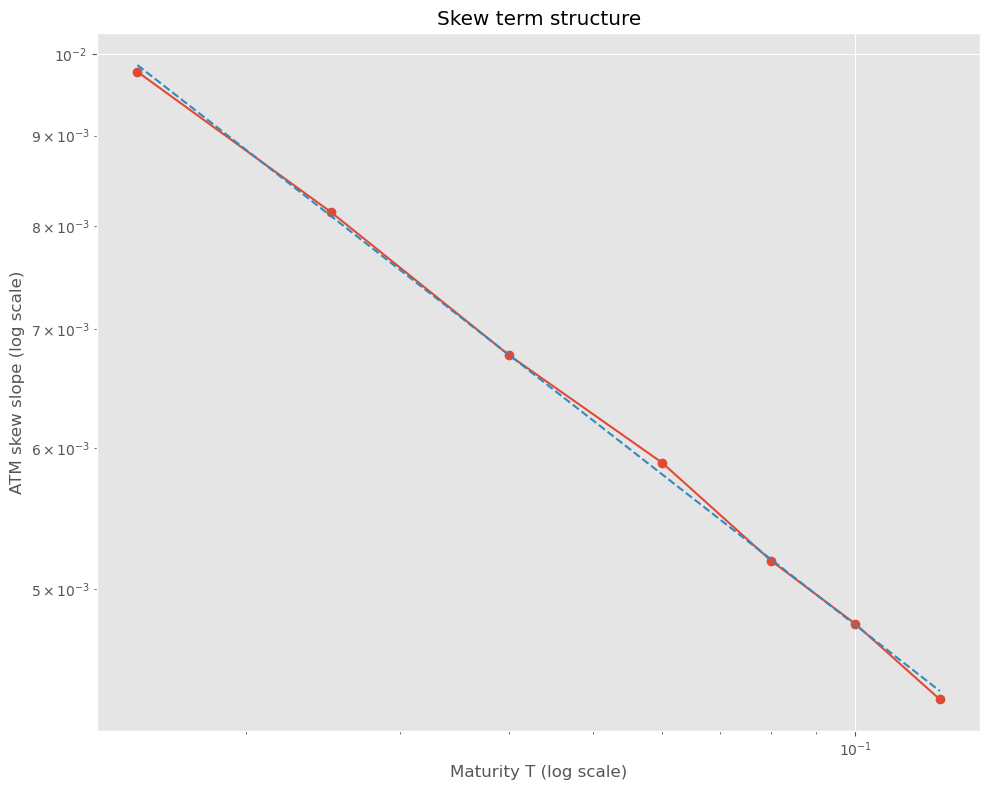

Implied Hurst Parameter (H): 0.1172


In [33]:
def AtmSkewTermStructure(S0, V0, mu, H, eta, rho, maturities, NumTrial=300000, strikeswindow=None):
    slopes = []
    if strikeswindow is None:
        strikeswindow = np.array([S0*0.96, S0*0.98, S0, S0*1.02, S0*1.04])
    
    
    for T in maturities:
        NumInterval = max(int(200*T),20) 
        Spaths, _ = RoughVolatilitySimulation(S0,V0,mu, H,eta,rho, T,NumInterval,NumTrial)
        finalprices =Spaths[-1]
        ivs = []

        
        for K in strikeswindow:
            if K<S0:
                optiontype = 'put'
                payoff= np.maximum(K-finalprices, 0)
            else:
                payoff= np.maximum(finalprices-K, 0)
                optiontype = 'call'
                
            mcprice = np.mean(payoff)*np.exp(-mu*T)
            ivs.append(ImpliedVolatility(S0,K, mu,T,mcprice,optiontype))

        
        ivs = np.array(ivs)
        valid = ~np.isnan(ivs)
        slope = np.polyfit(strikeswindow[valid],ivs[valid],1)[0]
        slopes.append(abs(slope))

    slopes = np.array(slopes)
    exponent,intercept = np.polyfit(np.log(maturities),np.log(slopes),1)

    return maturities, slopes, exponent

np.random.seed(50)

mats, slopes, exponent= AtmSkewTermStructure(100, 0.04, 0.02, 0.1, 1.5, -0.7,np.array([0.015, 0.025, 0.04, 0.06, 0.08, 0.10, 0.125]))

fig, ax = plt.subplots(figsize=(10, 8))
ax.loglog(mats, slopes, 'o-')
fit_line = np.exp(np.polyfit(np.log(mats), np.log(slopes), 1)[1]) * mats**exponent

ax.loglog(mats, fit_line, '--')
ax.set_xlabel('Maturity T (log scale)')
ax.set_ylabel('ATM skew slope (log scale)')
ax.set_title(f'Skew term structure')

plt.tight_layout()
plt.show()

print(f"Implied Hurst Parameter (H): {exponent + 0.5:.4f}")

So as described before, the plot shows the magnitude of at the money implied vol skew at different short dated maturities. The graph shows that these points lie on a straight line across the full range, which shows that the data is from rough volatility, and the power law relationship. In other words, the model's skew decay as a power of the maturity rather than some other functional form like Heston. Furthermore, by looking at the slope itself then adding back 0.5, we recover the implied hurst parameter of 0.1172, which is reasonably close to our goal of 0.1.